In [1]:
!pip install pretty_midi torch matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 44.3 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.8 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=0ec265e26dc41978f93270caf30fb5bbec5842b40ceef78992eb529a7e1c7ce5
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [2]:
DATA_PATH = "/kaggle/input/datasets/jihadjbjjuihhih/maestro"

In [3]:
import os



midi_files = []
for root, _, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".midi") or file.endswith(".mid"):
            midi_files.append(os.path.join(root, file))

print("Total MIDI files:", len(midi_files))

Total MIDI files: 1276


In [4]:
import pretty_midi
import numpy as np
from tqdm import tqdm

def midi_to_pianoroll(path, fs=16):
    try:
        midi = pretty_midi.PrettyMIDI(path)
        piano = midi.instruments[0]
        roll = piano.get_piano_roll(fs=fs)
        roll = (roll > 0).astype(np.float32)
        return roll.T
    except:
        return None

In [6]:
SEQ_LEN = 64

def create_sequences(data, seq_len=SEQ_LEN):
    sequences = []
    for i in range(0, len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return sequences

In [7]:
MAX_SEQ_PER_FILE = 300  # IMPORTANT

all_sequences = []

for file in tqdm(midi_files[:400]):
    roll = midi_to_pianoroll(file)

    if roll is not None and len(roll) > SEQ_LEN:
        seqs = create_sequences(roll)

        seqs = seqs[:MAX_SEQ_PER_FILE]  
        all_sequences.extend(seqs)

X = np.array(all_sequences)
print("Dataset shape:", X.shape)

100%|██████████| 400/400 [01:06<00:00,  6.04it/s]


Dataset shape: (119700, 64, 128)


In [9]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_tensor = torch.tensor(X)

dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [10]:
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=256, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc_enc = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = self.fc_enc(h[-1])

        dec_input = self.fc_dec(z).unsqueeze(1)
        dec_input = dec_input.repeat(1, x.size(1), 1)

        out, _ = self.decoder(dec_input)
        return out

model = LSTMAutoencoder()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMAutoencoder(
  (encoder): LSTM(128, 256, batch_first=True)
  (fc_enc): Linear(in_features=256, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=256, bias=True)
  (decoder): LSTM(256, 128, batch_first=True)
)

In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
EPOCHS = 50
losses = []

for epoch in range(EPOCHS):
    total_loss = 0

    for (batch,) in dataloader:
        batch = batch.to(device)

        output = model(batch)

        loss = criterion(output, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {avg_loss:.4f}")

Epoch 1/50 Loss: 0.0167
Epoch 2/50 Loss: 0.0145
Epoch 3/50 Loss: 0.0134
Epoch 4/50 Loss: 0.0125
Epoch 5/50 Loss: 0.0118
Epoch 6/50 Loss: 0.0112
Epoch 7/50 Loss: 0.0107
Epoch 8/50 Loss: 0.0103
Epoch 9/50 Loss: 0.0100
Epoch 10/50 Loss: 0.0097
Epoch 11/50 Loss: 0.0094
Epoch 12/50 Loss: 0.0092
Epoch 13/50 Loss: 0.0090
Epoch 14/50 Loss: 0.0088
Epoch 15/50 Loss: 0.0086
Epoch 16/50 Loss: 0.0085
Epoch 17/50 Loss: 0.0083
Epoch 18/50 Loss: 0.0082
Epoch 19/50 Loss: 0.0081
Epoch 20/50 Loss: 0.0080
Epoch 21/50 Loss: 0.0079
Epoch 22/50 Loss: 0.0078
Epoch 23/50 Loss: 0.0077
Epoch 24/50 Loss: 0.0076
Epoch 25/50 Loss: 0.0075
Epoch 26/50 Loss: 0.0075
Epoch 27/50 Loss: 0.0074
Epoch 28/50 Loss: 0.0073
Epoch 29/50 Loss: 0.0073
Epoch 30/50 Loss: 0.0072
Epoch 31/50 Loss: 0.0072
Epoch 32/50 Loss: 0.0071
Epoch 33/50 Loss: 0.0070
Epoch 34/50 Loss: 0.0070
Epoch 35/50 Loss: 0.0069
Epoch 36/50 Loss: 0.0069
Epoch 37/50 Loss: 0.0068
Epoch 38/50 Loss: 0.0068
Epoch 39/50 Loss: 0.0068
Epoch 40/50 Loss: 0.0068
Epoch 41/

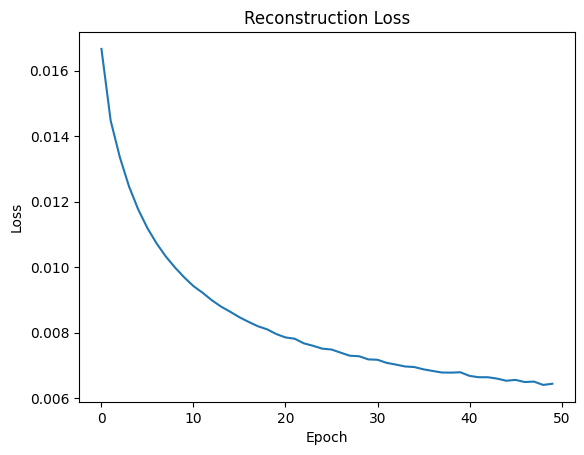

In [13]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
def pianoroll_to_midi(pianoroll, filename="output.mid", fs=16):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    pianoroll = 1 / (1 + np.exp(-pianoroll))  # sigmoid
    pianoroll = (pianoroll > 0.5).astype(int)

    for pitch in range(128):
        active = np.where(pianoroll[:, pitch] == 1)[0]

        for t in active:
            note = pretty_midi.Note(
                velocity=100,
                pitch=pitch,
                start=t / fs,
                end=(t+1) / fs
            )
            instrument.notes.append(note)

    midi.instruments.append(instrument)
    midi.write(filename)

In [15]:
def generate_sample(model, seq_len=64):
    model.eval()
    with torch.no_grad():
        z = torch.randn(1, 128).to(device)

        dec_input = model.fc_dec(z).unsqueeze(1)
        dec_input = dec_input.repeat(1, seq_len, 1)

        output, _ = model.decoder(dec_input)
        return output.cpu().numpy()[0]

In [16]:
OUTPUT_DIR = "kaggle/output/generated_music"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for i in range(5):
    sample = generate_sample(model)
    pianoroll_to_midi(sample, f"{OUTPUT_DIR}/sample_{i}.mid")

print("5 MIDI files generated!")

5 MIDI files generated!


In [17]:
CHECKPOINT_PATH = "/kaggle/working/model_full.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": 128,
    "hidden_dim": 256,
    "latent_dim": 128
}, CHECKPOINT_PATH)